## Station ALOHA data

### Figure 3
- Plot Qc time series and TSD-PP results for Gradients + Station ALOHA cruise

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
# ignore warnings
import warnings
warnings.simplefilter('ignore')

## load data
hourly_sf = pd.read_pickle('../data/hourly_sf_v1_all.pickle')
all_tsd = pd.read_pickle('../data/all_seaflow_tsd_mixed_v1_all.pickle')
final_rates = pd.read_pickle('../data/final_rates_v1_all.pickle')

In [4]:
##### Subsetting HOT and Gradients data #######
# HOT cruise example (2015 diel cruise)
hot_cruise_name = 'KM1513'
## only get subset for pro without missing data
hot_cruise_df = hourly_sf.loc[(hourly_sf['cruise']==hot_cruise_name)&(hourly_sf['pop']=='prochloro')].set_index('time')
hot_cruise_df= hot_cruise_df.loc['2015-07-25 16:00:00+00:00':'2015-08-03 13:00:00+00:00']
# resample hourly cruise data (fill missing with nans)
hot_cruise_resamp = hot_cruise_df.drop(columns=['sunrise','sunset']).resample('1H').agg(pd.Series.sum, min_count=1).reset_index()

# subset tsd data
hot_tsd_df = all_tsd.loc[(all_tsd['cruise']==hot_cruise_name)&(all_tsd['pop']=='prochloro')].drop_duplicates(subset=['time', 
                                                                                                                     'data_with_missing']).sort_values(by='time').set_index('time')
hot_tsd_df= hot_tsd_df.loc['2015-07-25 16:00:00+00:00':'2015-08-03 13:00:00+00:00'].reset_index()

# Gradients Cruise example (G1)
g_cruise_name = 'KOK1606'
## only get subset for pro without missing data
g_cruise_df = hourly_sf.loc[(hourly_sf['cruise']==g_cruise_name)&(hourly_sf['pop']=='prochloro')].set_index('time')
# g_cruise_df= g_cruise_df.loc['2015-07-25 16:00:00+00:00':'2015-08-03 13:00:00+00:00']
# resample hourly cruise data (fill missing with nans)
g_cruise_resamp = g_cruise_df.drop(columns=['sunrise','sunset']).resample('1H').agg(pd.Series.sum, min_count=1).reset_index()
# subset tsd data
g_tsd_df = all_tsd.loc[(all_tsd['cruise']==g_cruise_name)&(all_tsd['pop']=='prochloro')].drop_duplicates(subset=['time', 
                                                                                                                     'data_with_missing']).sort_values(by='time').set_index('time').reset_index()

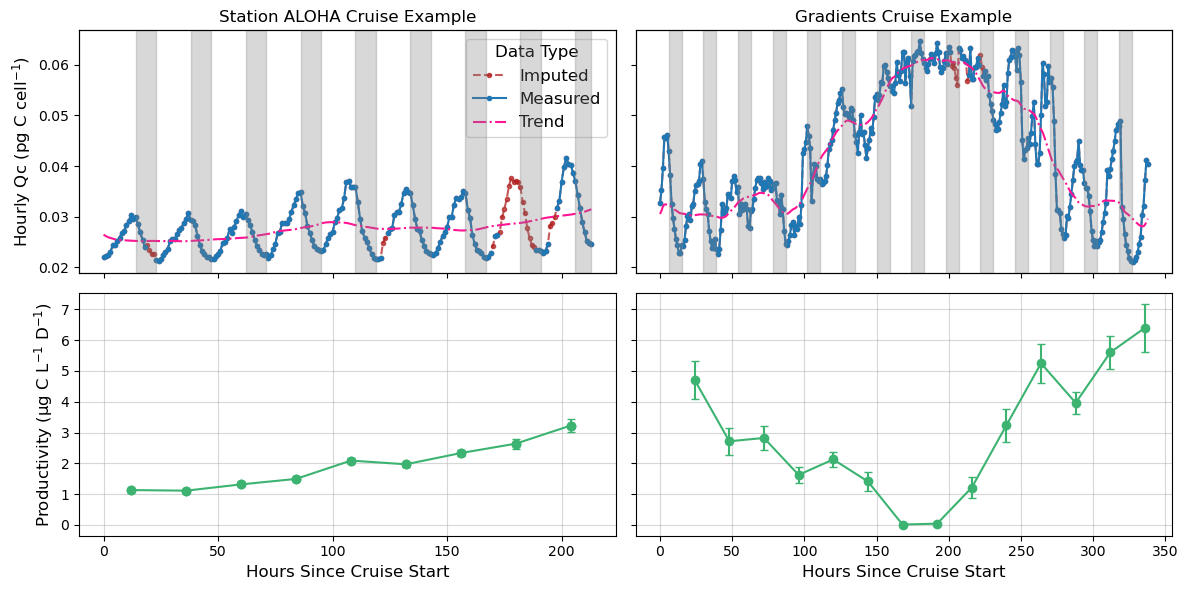

In [5]:
# create figure
fig, axs = plt.subplots(figsize=(12,6), nrows=2, ncols=2, sharex='col', sharey='row')
## plot time series data
# plot tsd data
x = np.arange(0, len(hot_tsd_df))
y = hot_tsd_df['data_with_missing']
axs[0][0].plot(hot_tsd_df['data_with_missing'], marker='.', c = 'firebrick', alpha=0.75, label='Imputed', linestyle='--')
# plot orignal data
hot_cruise_resamp['hour'] = hot_tsd_df['hour']
y = hot_cruise_resamp['Qc_hour']
axs[0][0].plot(x, y, marker='.', label='Measured')
# plot trend
y = hot_tsd_df['trend']
axs[0][0].plot(x, y, linestyle='-.', c='deeppink', label='Trend')
# plot diel cycle
twinax=axs[0][0].twinx()
twinax.fill_between(x, 0, 1, where=hot_tsd_df['time_of_day'] == 'night',color='gray', alpha=0.3, 
                    transform=axs[0][0].get_xaxis_transform())
# set y limits
ylims = axs[0][0].get_ylim()
twinax.set_ylim(ylims[0],ylims[1])
# # hide y ticks
twinax.tick_params(left=False, labelleft=False, top=False, labeltop=False,
                right=False, labelright=False, bottom=False, labelbottom=False)

## plot rates data
hot_cruise_rates = final_rates.loc[(final_rates['cruise']==hot_cruise_name)&(final_rates['pop']=='prochloro')]
# calculate hour and subset
hot_cruise_rates['hour'] = (hot_cruise_rates['cruise_day']*24)
hot_cruise_rates = hot_cruise_rates.loc[(hot_cruise_rates['hour'] >= 16)&(hot_cruise_rates['hour'] <= 229)]
# offset hours
hot_cruise_rates['hour'] = hot_cruise_rates['hour']-12
x = hot_cruise_rates['hour']
y = hot_cruise_rates['productivity']
yerr = hot_cruise_rates['productivity_se']
# plot growth + error bars (se)
axs[1][0].errorbar(x, y, yerr=yerr, capsize=3, ecolor = "mediumseagreen", color = "mediumseagreen", fmt='o')
l1 = axs[1][0].plot(x, y, c = 'mediumseagreen', label='Growth', marker='o')
# add grid
axs[1][0].grid(alpha=0.5)

## plot time series data
# plot tsd data
x = np.arange(0, len(g_tsd_df))
y = g_tsd_df['data_with_missing']
axs[0][1].plot(g_tsd_df['data_with_missing'], marker='.', c = 'firebrick', alpha=0.75, label='Imputed', linestyle='--')
# plot orignal data
g_cruise_resamp['hour'] = hot_tsd_df['hour']
y = g_cruise_resamp['Qc_hour']

axs[0][1].plot(x, y, marker='.', label='Measured')
# plot trend
y = g_tsd_df['trend']
axs[0][1].plot(x, y, linestyle='-.', c='deeppink', label='Trend')
# plot diel cycle
twinax=axs[0][1].twinx()
twinax.fill_between(x, 0, 1, where=g_tsd_df['time_of_day'] == 'night',color='gray', alpha=0.3, transform=axs[0][1].get_xaxis_transform())
# set y limits
ylims = axs[0][1].get_ylim()
twinax.set_ylim(ylims[0],ylims[1])
# # hide y ticks
twinax.tick_params(left=False, labelleft=False, top=False, labeltop=False,
                right=False, labelright=False, bottom=False, labelbottom=False)

## plot rates data
g_cruise_rates = final_rates.loc[(final_rates['cruise']==g_cruise_name)&(final_rates['pop']=='prochloro')]
# calculate hour and subset
g_cruise_rates['hour'] = g_cruise_rates['cruise_day']*24
# offset hours
g_cruise_rates['hour']-12
x = g_cruise_rates['hour']
y = g_cruise_rates['productivity']
yerr = g_cruise_rates['productivity_se']
# plot productivity + error bars (se)
axs[1][1].errorbar(x, y, yerr=yerr, capsize=3, ecolor = "mediumseagreen", color = "mediumseagreen", fmt='o', linestyle = '-')
# add grid
axs[1][1].grid(alpha=0.5)

## plot aesthetics
axs[0][0].legend(title='Data Type', fontsize=12, title_fontsize=12)
# axis labels
axs[1][0].set_xlabel('Hours Since Cruise Start', fontsize=12)
axs[0][0].set_ylabel('Hourly Qc (pg C $\mathregular{cell^{-1}}$)', fontsize=12)
axs[1][0].set_ylabel('Productivity (µg C $\mathregular{{L^{{-1}}}}$ $\mathregular{{D^{{-1}}}}$)', fontsize=12)
axs[1][1].set_xlabel('Hours Since Cruise Start', fontsize=12)

# titles
axs[0][0].set_title('Station ALOHA Cruise Example', fontsize=12)
axs[0][1].set_title('Gradients Cruise Example', fontsize=12)
plt.tight_layout()

## Figure 4: 
- Comparison with [Hynes et al. (2024)](https://doi.org/10.1002/lno.12683) model
- Monthly climatologies with [Rii et al. (2016)](https://doi.org/10.3354/meps11954) group-specific 14C data

#### Load and clean data from Hynes Model

In [9]:
## load data
sf_clean = pd.read_pickle('../data/sf_clean_long_all.pickle')
# results with new SeaFlow dataset (v1.6)
new_path='../data/hynes_model_results.csv'
hynes_df=pd.read_csv(new_path)

In [11]:
# clean time in HOT TSD-PP data
HOT_dates=pd.unique(sf_clean.loc[sf_clean['ALOHA']>0, 'time'].dt.round('1D').apply(lambda x: x.date()))
HOT_rates=final_rates.loc[final_rates['time'].isin(HOT_dates)]
# rename cols for merge
HOT_rates['model']='TSD'
HOT_rates['month'] = pd.to_datetime(HOT_rates['time']).dt.month
HOT_rates['year'] = pd.to_datetime(HOT_rates['time']).dt.year

# clean up hynes model df
# filter out crocosphaera
hynes_df=hynes_df.loc[hynes_df['pop']!='croco']
# rename euks for consistency
hynes_df.loc[hynes_df['pop']=='euk', 'pop'] = 'picoeuk'
# remove pvalues > 0.01 (not significant)
hynes_df = hynes_df.loc[hynes_df['r_p']<0.01]
# rename columns for consistency when merting
hynes_df.rename(columns={'date':'time','r': 'daily_growth_ant', 'r_se':'daily_se_ant', 
                           'PP_exp': 'productivity'}, inplace=True)
hynes_df['time']=pd.to_datetime(hynes_df['time']).dt.date
hynes_df['model']='Station ALOHA'

# merge with tsd data
both_data=HOT_rates.merge(hynes_df, on=['time','pop','cruise'], how='outer', suffixes=('_TSD', '_Hynes'))
both_data_s = HOT_rates[['time', 'month', 'year', 'cruise', 'pop', 
                         'productivity', 'model']].merge(hynes_df[['time', 'pop', 'cruise', 
                                                                     'productivity', 'year', 'month', 'model']], how='outer')

#### Are the Hynes model and TSD-PP significnatly different? 
- Not significantly different for growth rate (p = 0.42) or productivity (p = 0.82) (Mann-Whitney U-Test)

In [12]:
# calculate significnace between growth rate and productivity for both models
from scipy.stats import mannwhitneyu

# growth rate for each population
pops = ['prochloro', 'synecho', 'picoeuk']
tsd_growth = both_data.loc[both_data['daily_growth'].notnull(), 'daily_growth'].values
hynes_growth = both_data.loc[both_data['daily_growth_ant'].notnull(), 'daily_growth_ant'].values
stat, p_value = mannwhitneyu(tsd_growth, hynes_growth)
print(f'Growth Rate: p-value = {p_value}')
# yay they are the same

# productivity
tsd_prod = both_data.loc[both_data['productivity_TSD'].notnull(), 'productivity_TSD'].values
hynes_prod = both_data.loc[both_data['productivity_Hynes'].notnull(), 'productivity_Hynes'].values
stat, p_value = mannwhitneyu(tsd_prod, hynes_prod)
print(f'Productivity: p-value = {p_value}')

Growth Rate: p-value = 0.41904750342648
Productivity: p-value = 0.8178816854884587


In [13]:
## helper function to reformat dfs for plotting
def melt_dfs(df, tsd_col, sa_col):
    # get data where only 1 model ran
    tsd_only=both_data.loc[(both_data[tsd_col].notnull())&(both_data[sa_col].isnull())]
    sa_only=both_data.loc[(both_data[tsd_col].isnull())&(both_data[sa_col].notnull())]

    # melt df
    growth_models=pd.concat([tsd_only, sa_only])[[tsd_col,sa_col]]
    growth_models.rename(columns={tsd_col:'TSD', sa_col:'Hynes'}, inplace=True)
    growth_long=pd.melt(growth_models, 
            value_vars=['TSD','Hynes'],
           var_name='Model',
           value_name='var')
    return growth_long

### Figure 4A

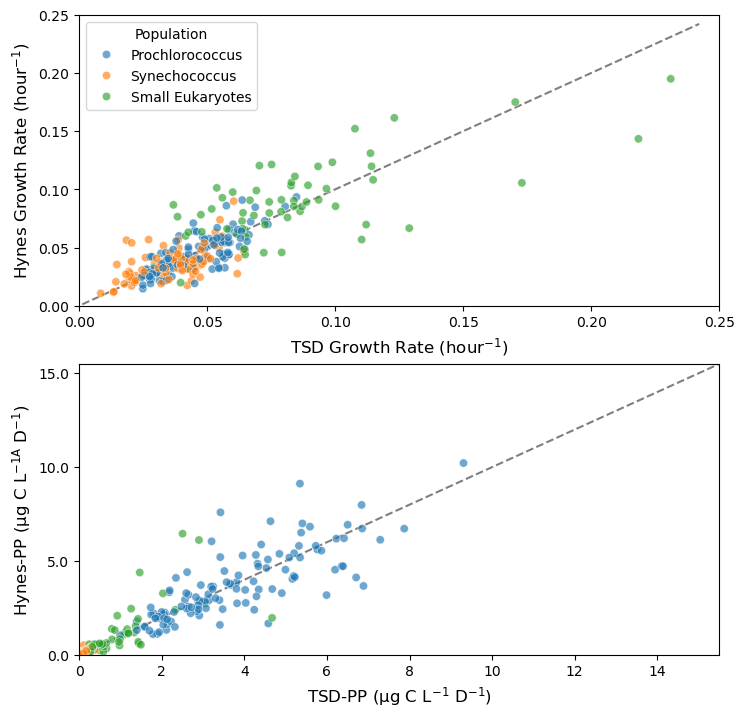

In [14]:
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns

# plot all pops together
widths = [4,2]
heights = [2,2]
gs_kw = dict(width_ratios=widths, height_ratios=heights)
fig,axs=plt.subplots(figsize=(8,8), nrows=2)
# plot growth rate
g=sns.scatterplot(both_data, x='daily_growth', y='daily_growth_ant', hue='pop', ax=axs[0], alpha=0.65)
lims = [
        np.min([axs[0].get_xlim(), axs[0].get_ylim()]),  # min of both axes
        np.max([axs[0].get_xlim(), axs[0].get_ylim()]),  # max of both axes
    ]
# plot 1:1
axs[0].plot(lims, lims, 'k-', alpha=0.5, zorder=0, linestyle='--')
axs[0].set_xlim(0,0.25)
axs[0].set_ylim(0,0.25)
# legend and labels
axs[0].set_xlabel('TSD Growth Rate ($\mathregular{hour^{-1}}$)', fontsize=12)
axs[0].set_ylabel('Hynes Growth Rate ($\mathregular{hour^{-1}}$)', fontsize=12)
handles, labels = axs[0].get_legend_handles_labels()
legend_labels = ['Prochlorococcus', 'Synechococcus', 'Small Eukaryotes']
axs[0].legend(handles, legend_labels, title='Population', loc='upper left', fontsize=10, title_fontsize=10)

# # plot productivity
g=sns.scatterplot(both_data, x='productivity_TSD', y='productivity_Hynes', 
                  hue='pop', ax=axs[1], alpha=0.65, legend=False)
lims = [
        np.min([axs[1].get_xlim(), axs[1].get_ylim()]),  # min of both axes
        np.max([axs[1].get_xlim(), axs[1].get_ylim()]),  # max of both axes
    ]
# plot 1:1
axs[1].plot(lims, lims, 'k-', alpha=0.5, zorder=0, linestyle='--')
# legend and labels
axs[1].set_xlabel('TSD-PP (µg C $\mathregular{L^{-1}}$ $\mathregular{D^{-1}}$)', fontsize=12)
axs[1].set_ylabel('Hynes-PP (µg C $\mathregular{L^{-1A}}$ $\mathregular{D^{-1}}$)', fontsize=12)
axs[1].set_xlim(0,15.5)
axs[1].set_ylim(0,15.5)
axs[1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# # set the spacing between subplots
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.3, 
                    hspace=0.2)
plt.rcParams.update({'font.size':15})
plt.show()

#### Load and clean data from Rii et al. 2016
- Requires an API key from [Simons CMAP](https://simonscmap.com/apikeymanagement)
- Replace `api_key` with your own key by copy/paste OR create your own .env file

In [15]:
# pull data from Simons CMAP
from dotenv import load_dotenv
import os
import pycmap

# grab API key from hidden file
load_dotenv()
api_key = os.getenv("API_KEY")  
# load api key from CMAP
api = pycmap.API(token=api_key)


In [16]:
## load group specific data from 2012
rii_group=api.get_dataset('tblHOT242_252_14C_PP_WSW_group_sort')
# resolve time and get months
rii_group['time']=pd.to_datetime(rii_group['time'])
rii_group['month']=rii_group['time'].dt.month
# only get surface samples
surface=rii_group.loc[rii_group['depth']<=25]
# melt df
cols=['month','C14_assimilation_prochlorococcus',
        'C14_assimilation_synechococcus','C14_assimilation_pico']
surface=surface[cols]
surface.rename(columns={cols[1]:'prochloro', cols[2]: 'synecho', cols[3]: 'picoeuk'}, inplace=True)
surface_long=pd.melt(surface, id_vars=['month'], var_name='pop',value_name='C14_assimilation')
# convert µmol to g (molar mass=18.035 g/mol according to NIH)
surface_long['C14_assimilation_ug']=surface_long['C14_assimilation']*18.035

## subset TSD-PP data
# make a copy of hot_rates df 
hot_cruises = HOT_rates.copy()
hot_cruises['time'] = pd.DatetimeIndex(hot_cruises['time']).tz_localize('UTC')
hot_cruises['month'] = hot_cruises['time'].dt.month

### Figure 4B


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


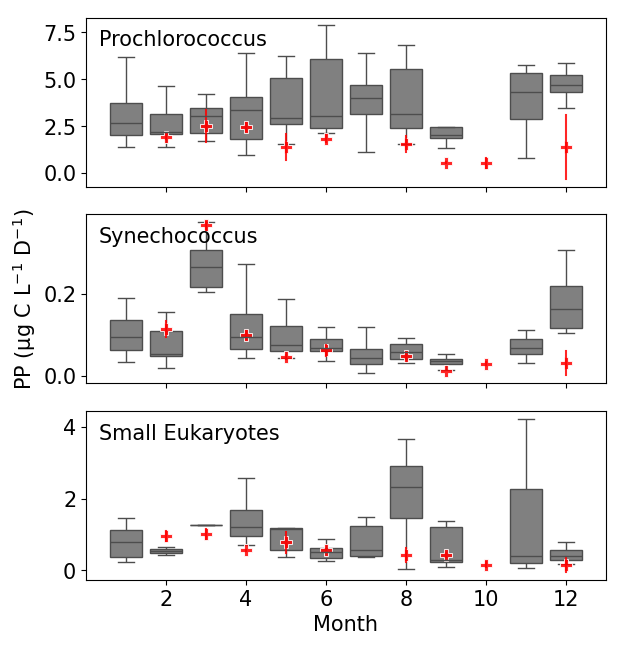

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.lines import Line2D

fig,axs=plt.subplots(figsize=(7,7), nrows=3, sharex=True)
hot_cruises['pop_order'] = pd.Categorical(hot_cruises['pop'], categories=['prochloro', 'synecho', 'picoeuk'])
# plot each population
counter=0
colors=['#1f77b4','#ff7f0e','#2ca02c']
pops=['prochloro','synecho','picoeuk']
pop_names = ['Prochlorococcus', 'Synechococcus', 'Small Eukaryotes']
legends=[]
for pop,color, pop_name in zip(pops,colors,pop_names):
    # divide axes to break (but skip pro)
    ax = axs[counter]
    # subset df
    pop_df=hot_cruises.loc[hot_cruises['pop']==pop].sort_values(by='month')
    # plot population by productivity
    g=sns.boxplot(data=pop_df, x='month',y='productivity', color='gray',ax=ax, native_scale=True, 
                  showfliers=False)
    g.set(xlabel=None, ylabel=None)
    sample_sizes = pop_df.groupby(['month'])['productivity'].count().values
    # add text for sample size
    for i, box in enumerate(ax.artists):
        print(box)
        x = box.get_x() + box.get_width() / 2
        y = box.get_ydata()[4]  # Get the top whisker position
        text = f"n = {sample_sizes[i]}"
        plt.text(x, y, text, ha='center', va='bottom')
    # make legend if pro
    ln=ax.legend(title=pop_name, frameon=False, fontsize=10, loc='upper left')
    # save legend
    legends.append(ln)
    # plot 14C data as plus signs
    surface_df=surface_long.loc[surface_long['pop']==pop].sort_values(by='month')
    g2=sns.lineplot(data=surface_df, x='month',y='C14_assimilation_ug',
                   color='red', marker='P', markersize=8,linestyle='', errorbar = 'sd', err_style='bars', 
                   ax=ax,legend=False, alpha=0.85)
    g.set(xlabel=None, ylabel=None)
    counter+=1

fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.ylabel('PP (µg C $\mathregular{L^{-1}}$ $\mathregular{D^{-1}}$)')
# custom legend
legend_elements = [Line2D([0], [0], marker='s',color='gray', label='TSD', linestyle='',markersize=8),]
                #    Line2D([0], [0], marker='P', color='r', label='14C',linestyle='',markersize=8)]
# add legends back
# l2=plt.legend(handles=legend_elements, loc='upper right', title='Measurement Type',
#               fontsize=12, title_fontsize=12, bbox_to_anchor=(1,0.3))
# plt.gca().add_artist(ln)
axs[2].set_xlabel('Month')
plt.tight_layout()
# axs[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.rcParams.update({'font.size':15})
plt.show()

### Summed TSD-PP and Size fractionated data
- Does TSD-PP match with size fractionated 14C data?

In [19]:
# get dataset from cmpa
sf_rii = api.get_dataset('tblHOT242_252_14C_PP_02_3')
# only get surface (<25m)
rii_surface = sf_rii.loc[sf_rii['depth']<= 25]

# convert µmol to g (molar mass=18.035 g/mol according to NIH)
rii_surface['C14_assimilation_pico_mean']=rii_surface['C14_assimilation_pico_mean']*18.035
rii_surface['C14_assimilation_pico_stdev']=rii_surface['C14_assimilation_pico_stdev']*18.035

# Calculate pooled standard deviation for each month (triplicates: n=3 per row)
def pooled_stdev(group):
    n = 3
    stdevs = group['C14_assimilation_pico_stdev'].dropna()
    pooled_var = ((n - 1) * (stdevs ** 2)).sum() / (n * len(stdevs) - 1)
    return np.sqrt(pooled_var)

# get each month
rii_surface['month'] = pd.to_datetime(rii_surface['time']).dt.month
# Calculate average C14 assimilation per month
monthly_means = rii_surface.groupby('month')['C14_assimilation_pico_mean'].mean()
monthly_pooled_stdev = rii_surface.groupby('month').apply(pooled_stdev)

# Combine and export results
result_rii_sf = pd.DataFrame({
    'monthly_mean': monthly_means,
    'monthly_pooled_stdev': monthly_pooled_stdev
}).reset_index()

### Figure S6

Text(0.5, 1.0, '0.2 - 3µm Size Fractionated PP')

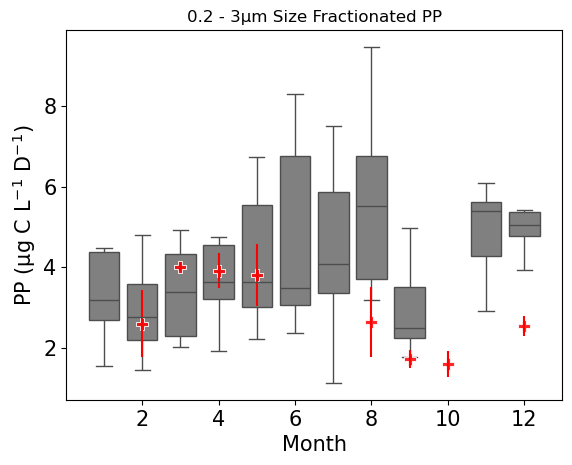

In [21]:
# only select for days that have measurements for all 3 pops
hot_count = hot_cruises.groupby(['cruise', 'month', 'cruise_day'])['productivity'].count().reset_index()
sum_idx = hot_count.loc[hot_count['productivity'] >= 2].index
# sum hot cruises per day
summed_tsd = hot_cruises.groupby(['cruise', 'month', 'cruise_day'])['productivity'].sum().reset_index()
summed_tsd = summed_tsd.loc[sum_idx]

# plot total summed TSD-PP and size fractionated 14C-PP
fig, ax = plt.subplots()
# plot summed TSD-PP
sns.boxplot(data=summed_tsd, x='month',y='productivity', color='gray',ax=ax, native_scale=True, 
                  showfliers=False)
# plot SF 14C-PP
sns.lineplot(data=result_rii_sf, x='month',y='monthly_mean',
                   color='red', marker='P', markersize=8,linestyle='',err_style='bars', 
                   ax=ax,legend=False, alpha=0.85)
ax.errorbar(x = result_rii_sf['month'], y = result_rii_sf['monthly_mean'], 
             yerr = result_rii_sf['monthly_pooled_stdev'], c = 'r', linestyle = '')
ax.set_xlabel('Month')
ax.set_ylabel('PP (µg C $\mathregular{L^{-1}}$ $\mathregular{D^{-1}}$)')
ax.set_title('0.2 - 3µm Size Fractionated PP', fontsize = 12)

### Small phytoplankton contribution to community PP
- Small phytoplankton TSD-PP and Bulk 14C measurements

In [22]:
## Pull data from CMAP
HOT_all= api.get_dataset('tblHOT_PP_v2022')
## data cleaning
## fix time
HOT_all['time']=pd.DatetimeIndex(HOT_all['time']).tz_localize('UTC')
# save exact time and round to days
HOT_all['exact_time']=HOT_all['time']
HOT_all['time']=HOT_all['time'].dt.round('1d')
HOT_all['year']=HOT_all['time'].dt.year
HOT_all['month']=HOT_all['time'].dt.month
# filter out for light incubations and use 2015-2022 data
HOT_surface=HOT_all.loc[(HOT_all['l12'].notnull())&(HOT_all['depth']<=25) & (HOT_all['year'] >= 2015)]
## merge with tsd data
# get just picophytoplankton totals
hot_cruises['year'] = hot_cruises['time'].dt.year
pico_prod=hot_cruises.groupby(['time','month','pop']).sum().reset_index()
monthly_hot_tsd=pico_prod.groupby(['month', 'pop']).agg({
    'productivity':['mean','sem']
})
# fix columns
monthly_hot_tsd.columns=['_'.join(col).strip() for col in monthly_hot_tsd.columns.values]
monthly_hot_tsd=monthly_hot_tsd.reset_index()
# get monthly HOT PP values
monthly_hot_PP=HOT_surface.groupby(['month']).agg({
    'l12':['mean','sem']
})
# fix columns
monthly_hot_PP.columns=['_'.join(col).strip() for col in monthly_hot_PP.columns.values]
monthly_hot_PP=monthly_hot_PP.reset_index()

### Figure 6A

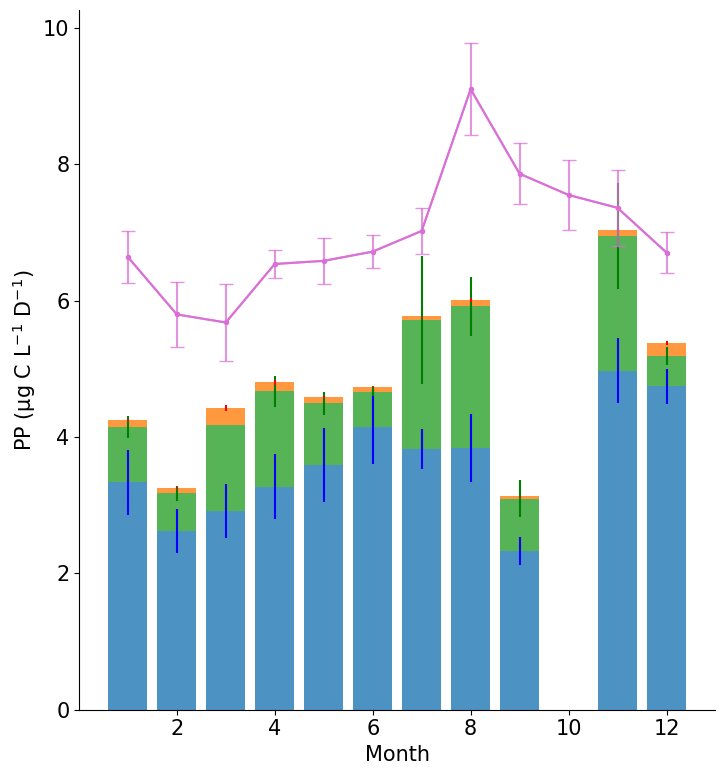

In [23]:
# create data
monthly_tsd_wide=monthly_hot_tsd.pivot(index='month',columns='pop')
monthly_tsd_wide.columns=['_'.join(col).strip() for col in monthly_tsd_wide.columns.values]
monthly_tsd_wide=monthly_tsd_wide.reset_index()
# make plot
fig,axs=plt.subplots(figsize=(7.5,8))
x=monthly_tsd_wide['month']
pro = monthly_tsd_wide['productivity_mean_prochloro']
syn = monthly_tsd_wide['productivity_mean_synecho']
picoeuk = monthly_tsd_wide['productivity_mean_picoeuk']

## plot stacked bar plots of TSD estimated Picoeukaryotes
bar1=axs.bar(x, pro, label='Prochlorococcus',
        yerr=monthly_tsd_wide['productivity_sem_prochloro'], ecolor='blue', alpha=0.8)
# plot picoeuk
bar2=axs.bar(x, picoeuk, bottom=pro, label='Small Eukaryotes',yerr=monthly_tsd_wide['productivity_sem_picoeuk'], 
        ecolor='green', color='tab:green', alpha=0.8)
# plot syn
bar3=axs.bar(x, syn, bottom=pro+picoeuk, label='Synechococcus',yerr=monthly_tsd_wide['productivity_sem_synecho'], 
        ecolor='red', alpha=0.8)

# set legend for bar plots
lns=[bar1]+[bar2]+[bar3]
labs = [l.get_label() for l in lns]
# l1=axs.legend(lns, labs, title='TSD Estimates', fontsize=12, title_fontsize=12,
#              loc="upper center", bbox_to_anchor=(0.16, 1.06))

# plot community
axs.plot(monthly_hot_PP['month'], monthly_hot_PP['l12_mean'], marker='.', 
            c='orchid', label='Community')
# plot error
lower_err=monthly_hot_PP['l12_sem']
upper_err=monthly_hot_PP['l12_sem']
yerr=[lower_err, upper_err]
ln4=axs.errorbar(monthly_hot_PP['month'], monthly_hot_PP['l12_mean'], yerr=yerr, color='orchid',alpha=0.75,
            capsize=5, label='Community')
## community
axs.set_ylabel('PP (µg C $\mathregular{L^{-1}}$ $\mathregular{D^{-1}}$)')
axs.set_xlabel('Month')
# get all axis labels
lns=[ln4]
labs = [l.get_label() for l in lns]
# l2=axs.legend(lns, labs, title='14C Measurements',
#              fontsize=12, title_fontsize=12,loc="upper center", bbox_to_anchor=(0.86, 1.06))
# plt.gca().add_artist(l1)

# despine
# Hide the top and right spines
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
# make labels
# axs[1].set_ylabel('Net Productivity (µg C $\mathregular{L^{-1}}$ $\mathregular{D^{-1}}$)')
axs.set_xlabel('Month')
# axs[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.rcParams.update({'font.size':15})
# sns.despine(left=True, bottom=True)
plt.tight_layout()